In [57]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad
import hdf5plugin

from scipy.stats import gamma, expon, poisson, shapiro
from scipy import sparse
import statsmodels.api as sm

import importlib

In [40]:
importlib.reload(mpl)
mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 14,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 14,            # axis-label size matches body text
    'xtick.labelsize'     : 11,             # tick labels one point smaller
    'ytick.labelsize'     : 11,
    'legend.fontsize'     : 11,             # legend text one point smaller
    'figure.titlesize'    : 20,
    
    #'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
    #    '#0072B2', '#D55E00', '#009E73',
    #    '#E69F00', '#CC79A7', '#56B4E9',
    #]),
    
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
})

prop_cycle = [c["color"] for c in list(mpl.rcParams["axes.prop_cycle"])]

# Import Data:

In [3]:
norman_data = sc.read_h5ad("Data/Experimental/Norman19/perturb_norm.h5ad")
replogle_data = sc.read_h5ad("Data/Experimental/Replogle22/perturb_norm.h5ad")

In [4]:
norman_data = norman_data[norman_data.obs["perturbation"]=="ctrl"]
replogle_data = replogle_data[replogle_data.obs["perturbation"]=="ctrl"]
#sc.pp.calculate_qc_metrics(norman_data,inplace=True,log1p=True,layer="log1p")
#sc.pp.calculate_qc_metrics(replogle_data,inplace=True,log1p=True,layer="log1p")

In [5]:
grins_data_full = sc.read_h5ad("Data/Projects/KeggoRo/perturb_norm_ctrl_nm.h5ad")

In [6]:
grins_data = sc.read_h5ad("Data/Projects/KeggoRo/perturb_norm_ctrl_clustered.h5ad")

In [7]:
grins_data_red = sc.read_h5ad("Data/Projects/KeggoRo/perturb_norm_ctrl_reduced.h5ad")

# Control Data Comparison:

In [9]:
cs = [0,1,2]
names = ["Norman19","Replogle22","uGRiNS with missingness filter"]
data = [norman_data,replogle_data,grins_data]

KeyboardInterrupt: 

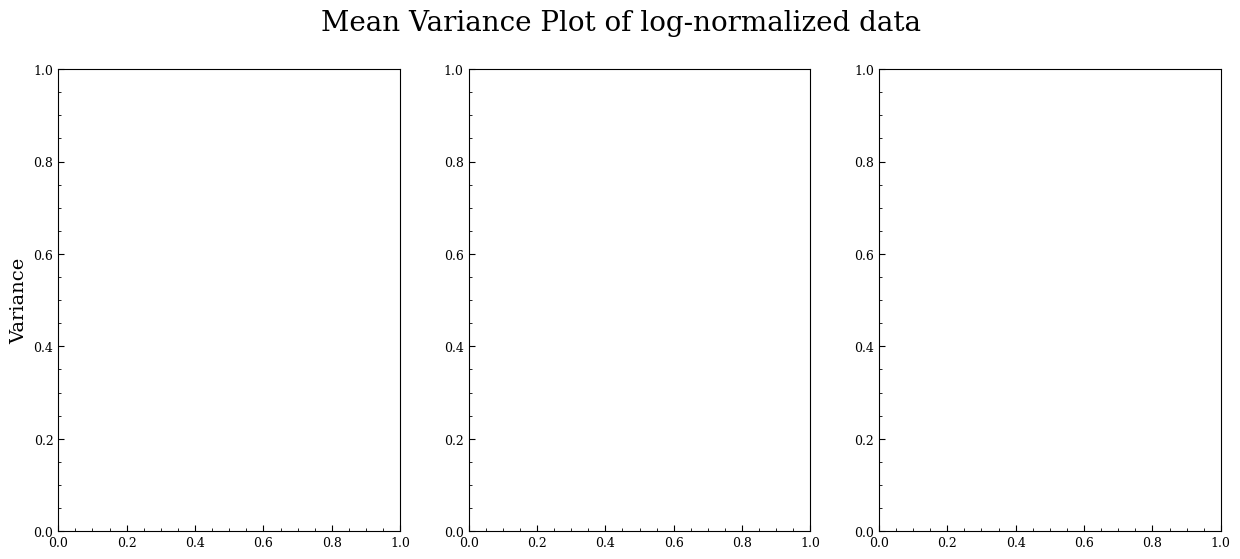

In [79]:
cs = [0,1,2]
names = ["Norman19","Replogle22","m+uGRiNS"]
data = [norman_data,replogle_data,grins_data]
fig, axs = plt.subplots(1,3,figsize=(15,6))
cs = [0,1,6]
axs[0].set_ylabel("Variance")
plt.suptitle("Mean Variance Plot of log-normalized data")
for i, adata in zip(range(len(cs)),data):#,replogle_data,grins_data]:
    if i == 2:
        layer = adata.layers["missing_log1p"]
    else:
        layer = adata.layers["log1p"]
    a_mean = np.asarray(layer.mean(axis=0)).squeeze()
    a_squared = layer.multiply(layer)
    a_var = np.asarray(np.mean(a_squared,axis=0)).squeeze()-a_mean*a_mean
    axs[i].scatter(a_mean,a_var,s=2,c=prop_cycle[cs[i]])
    axs[i].set_title(f"{names[i]}")
    axs[i].set_xlabel("Mean",fontsize=14)
plt.tight_layout()
plt.savefig("Prep_Data/Plots/mean_variance.png")
plt.show()

In [ ]:
# MA Plot

# Missingness Analysis:

## Across Genes:

In [10]:
from tqdm import tqdm
mean_nzs = []
for i in range(len(data)):
    ds = data[i]
    layer = ds.layers["log1p"].tocsc()
    non_zero_entries = np.split(layer.indices,layer.indptr[1:-1])
    mean_nz = []
    for j in tqdm(range(len(non_zero_entries))):
        non_zero_exprs = (layer[non_zero_entries[j],j]).todense().T
        if non_zero_exprs.shape[1] < 1:
            mean_nz.append(0)
            continue
        mean_nz.append(np.mean(non_zero_exprs))
    mean_nzs.append(mean_nz)

100%|██████████| 4676/4676 [00:11<00:00, 402.37it/s]


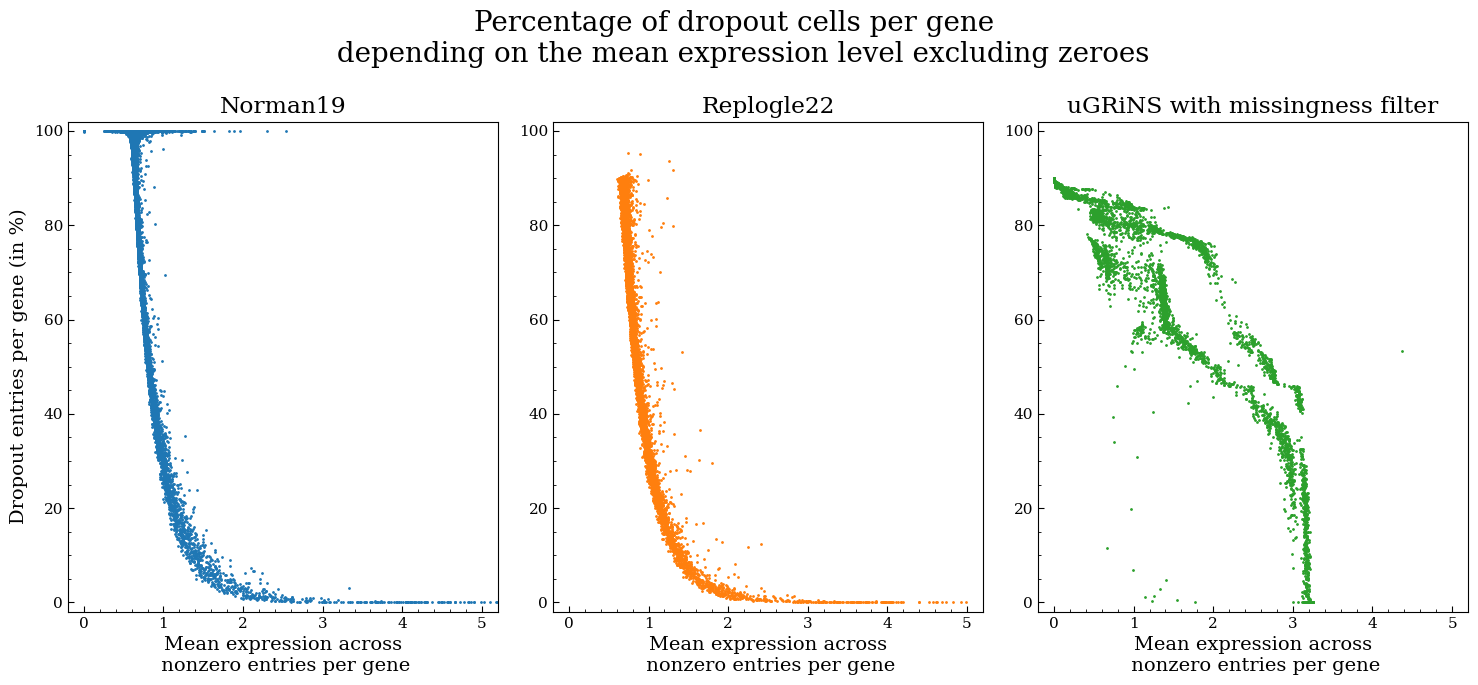

In [42]:

fig, axs = plt.subplots(1,3,figsize=(15,7))
axs[0].set_ylabel("Dropout entries per gene (in %)")

for i in range(len(axs)):
    ax = axs[i]
    ax.scatter(mean_nzs[i],data[i].var["pct_dropout_by_counts"],s=1,color=prop_cycle[cs[i]])
    ax.set_xlim(-0.2,5.2)
    ax.set_ylim(-2,102)
    ax.set_xlabel("Mean expression across\n nonzero entries per gene")
    ax.set_title(names[i])

plt.suptitle("Percentage of dropout cells per gene \n depending on the mean expression level excluding zeroes")
plt.tight_layout()
plt.savefig("Prep_Data/Plots/missingness_genewise_nzmean.png")
plt.show()

/tmp/ipykernel_1449774/2891557634.py:15: RuntimeWarning: invalid value encountered in divide
  replogle_scaling_factor = np.nanmean(replogle_y/dense_replogle_y) # PDF was fitted on dense replogle, but for comparison of Norman & Replogle, actual counts are better -> scale PDF by this factor


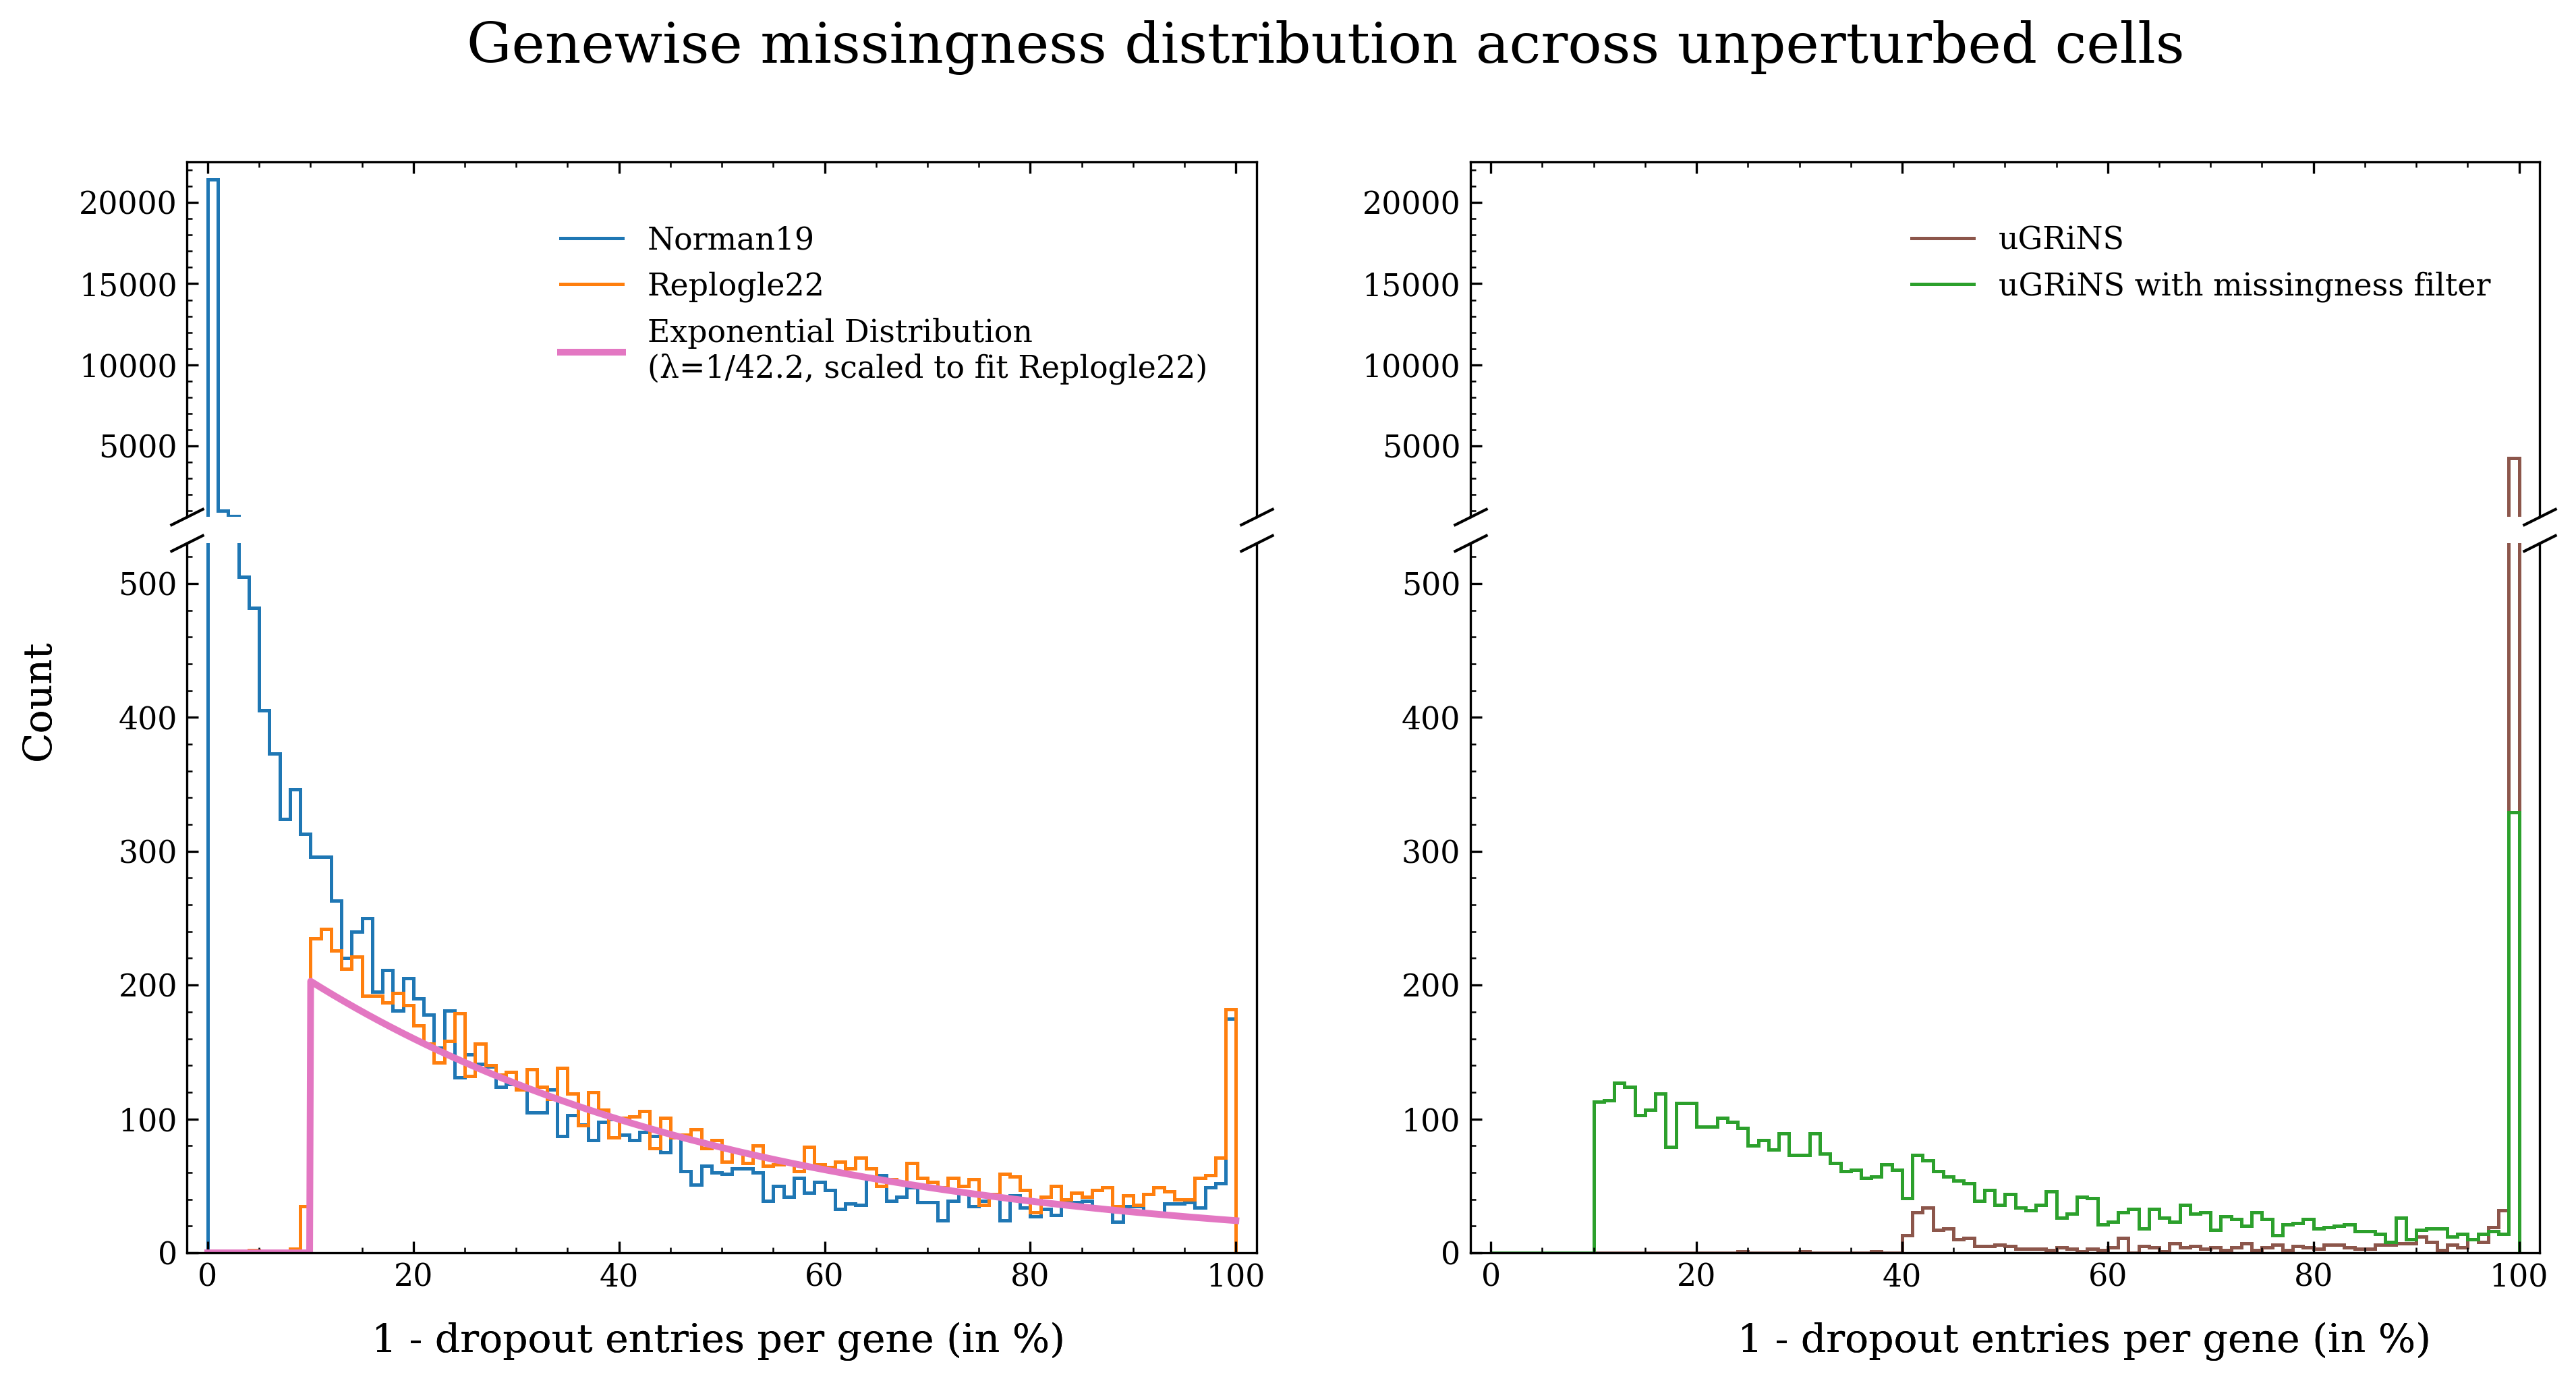

In [41]:
fig, axs = plt.subplots(2, 2, sharex="col",figsize=(15,7),dpi=300,height_ratios=[1,2])
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

bins = 100
replogle_y, replogle_x = np.histogram(list(100-replogle_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))
norman_y, norman_x = np.histogram(list(100-norman_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))

grins_y, grins_x = np.histogram(list(100-grins_data_full.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))
miss_grins_y, miss_grins_x = np.histogram(list(100-grins_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100))

dense_replogle_y, dense_replogle_x = np.histogram(list(100-replogle_data.var["pct_dropout_by_counts"]),bins=bins,range=(0,100),density=True)
pdf_mean = np.mean(100-replogle_data.var["pct_dropout_by_counts"])
pdf_fitted = expon.pdf(np.linspace(0,100,1000),loc=10,scale=pdf_mean)

replogle_scaling_factor = np.nanmean(replogle_y/dense_replogle_y) # PDF was fitted on dense replogle, but for comparison of Norman & Replogle, actual counts are better -> scale PDF by this factor
lw = 1.2
for j in range(2):
    ax1 = axs[0,j]
    ax2 = axs[1,j]
    if j == 0:
        ax1.stairs(norman_y,norman_x,label="Norman19",color=prop_cycle[0],lw=lw) # fill=True, alpha=0.7(?)
        ax2.stairs(norman_y,norman_x,color=prop_cycle[0],lw=lw)

        ax1.stairs(replogle_y,replogle_x, label="Replogle22",color=prop_cycle[1],lw=lw)
        ax2.stairs(replogle_y,replogle_x,color=prop_cycle[1],lw=lw)
    
        ax2.plot(np.linspace(0,100,1000),replogle_scaling_factor*pdf_fitted,color=prop_cycle[6],lw=2*lw)
        ax1.plot(np.linspace(0,100,1000),replogle_scaling_factor*pdf_fitted,color=prop_cycle[6],lw=2*lw,label=f"Exponential Distribution \n(λ=1/{np.round(pdf_mean,2)}, scaled to fit Replogle22)")

    else:
        ax1.stairs(grins_y,grins_x, label="uGRiNS",color=prop_cycle[5],lw=lw)
        ax2.stairs(grins_y,grins_x,color=prop_cycle[5],lw=lw)

        ax1.stairs(miss_grins_y,miss_grins_x, label="uGRiNS with missingness filter",color=prop_cycle[2],lw=lw)
        ax2.stairs(miss_grins_y,miss_grins_x,color=prop_cycle[2],lw=lw)


    ax2.set_ylim(0,530)
    ax1.set_ylim(650,22500)

    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    fig.text(0.3, 0.04, '1 - dropout entries per gene (in %)', ha='center')
    fig.text(0.75, 0.04, '1 - dropout entries per gene (in %)', ha='center')
    fig.text(0.07, 0.5, 'Count', va='center', rotation='vertical')
    ax1.legend(loc="upper right",bbox_to_anchor=(0.98,0.9))
    plt.suptitle("Genewise missingness distribution across unperturbed cells")
plt.savefig("Prep_Data/Plots/missingness_genewise.png")
plt.show()

## Across Cells:

In [13]:
cs = [0,1,2,5]
names = ["Norman19","Replogle22","uGRiNS with missingness filter","uGRiNS"]
data = [norman_data,replogle_data,grins_data, grins_data_full]

/storage/mi/sommereg03/vbsc_2/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10598.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.99384220266055), pvalue=np.float64(6.2784188332103834e-21)) ShapiroResult(statistic=np.float64(0.977845397922466), pvalue=np.float64(5.421526382750889e-10))


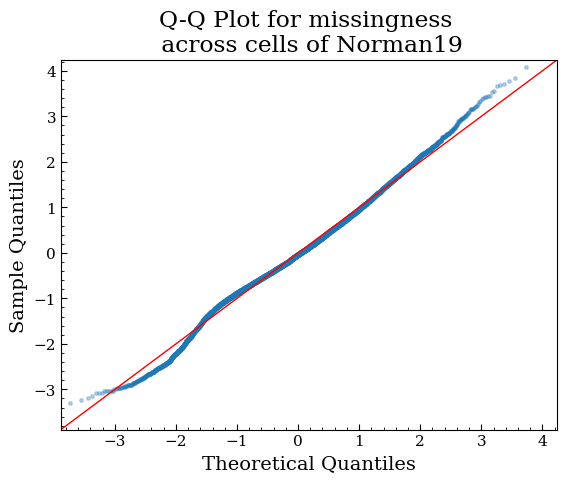

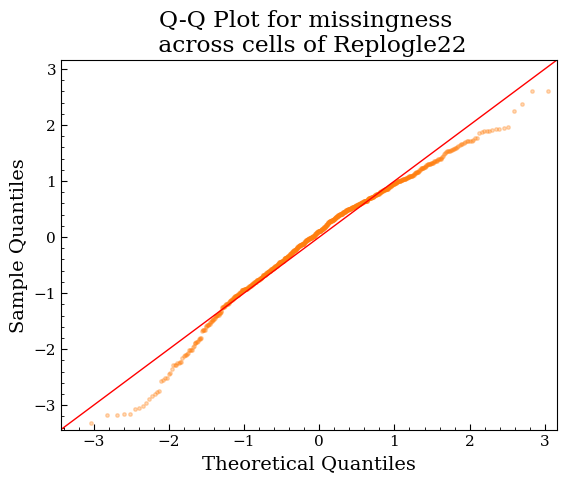

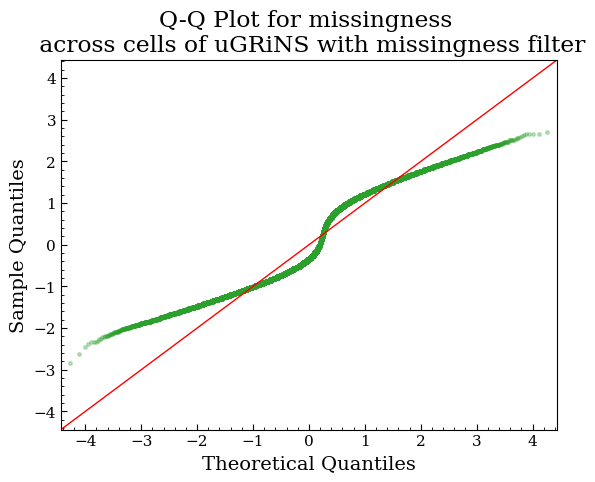

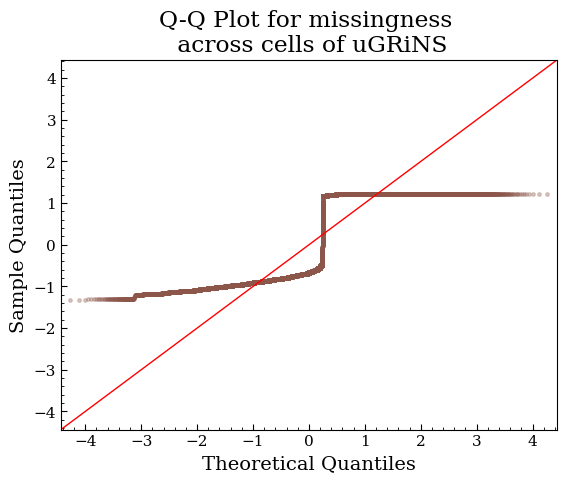

In [58]:
print(shapiro(norman_data.obs["n_genes_by_counts"]),shapiro(replogle_data.obs["n_genes_by_counts"]))
pps = [sm.ProbPlot(norman_data.obs["n_genes_by_counts"], fit=True),
    sm.ProbPlot(replogle_data.obs["n_genes_by_counts"], fit=True),
    sm.ProbPlot(grins_data.obs["n_genes_by_counts"], fit=True),
    sm.ProbPlot(grins_data_full.obs["n_genes_by_counts"], fit=True)]
for i in range(len(pps)):
    qq = pps[i].qqplot(marker='.', markerfacecolor=prop_cycle[cs[i]], markeredgecolor=prop_cycle[cs[i]], alpha=0.3,markersize=5)#,axs=[0,0])
    sm.qqline(qq.axes[0], line='45', fmt='r--',lw=1)
    plt.title(f"Q-Q Plot for missingness \n across cells of {names[i]}")

    plt.savefig(f"Prep_Data/Plots/missingness_qq_{names[i]}.png")
    plt.show()
    
# Not perfectly normal, but approximatively so
# uGRiNS (esp. m+uGRiNS) has two approx-normal sections

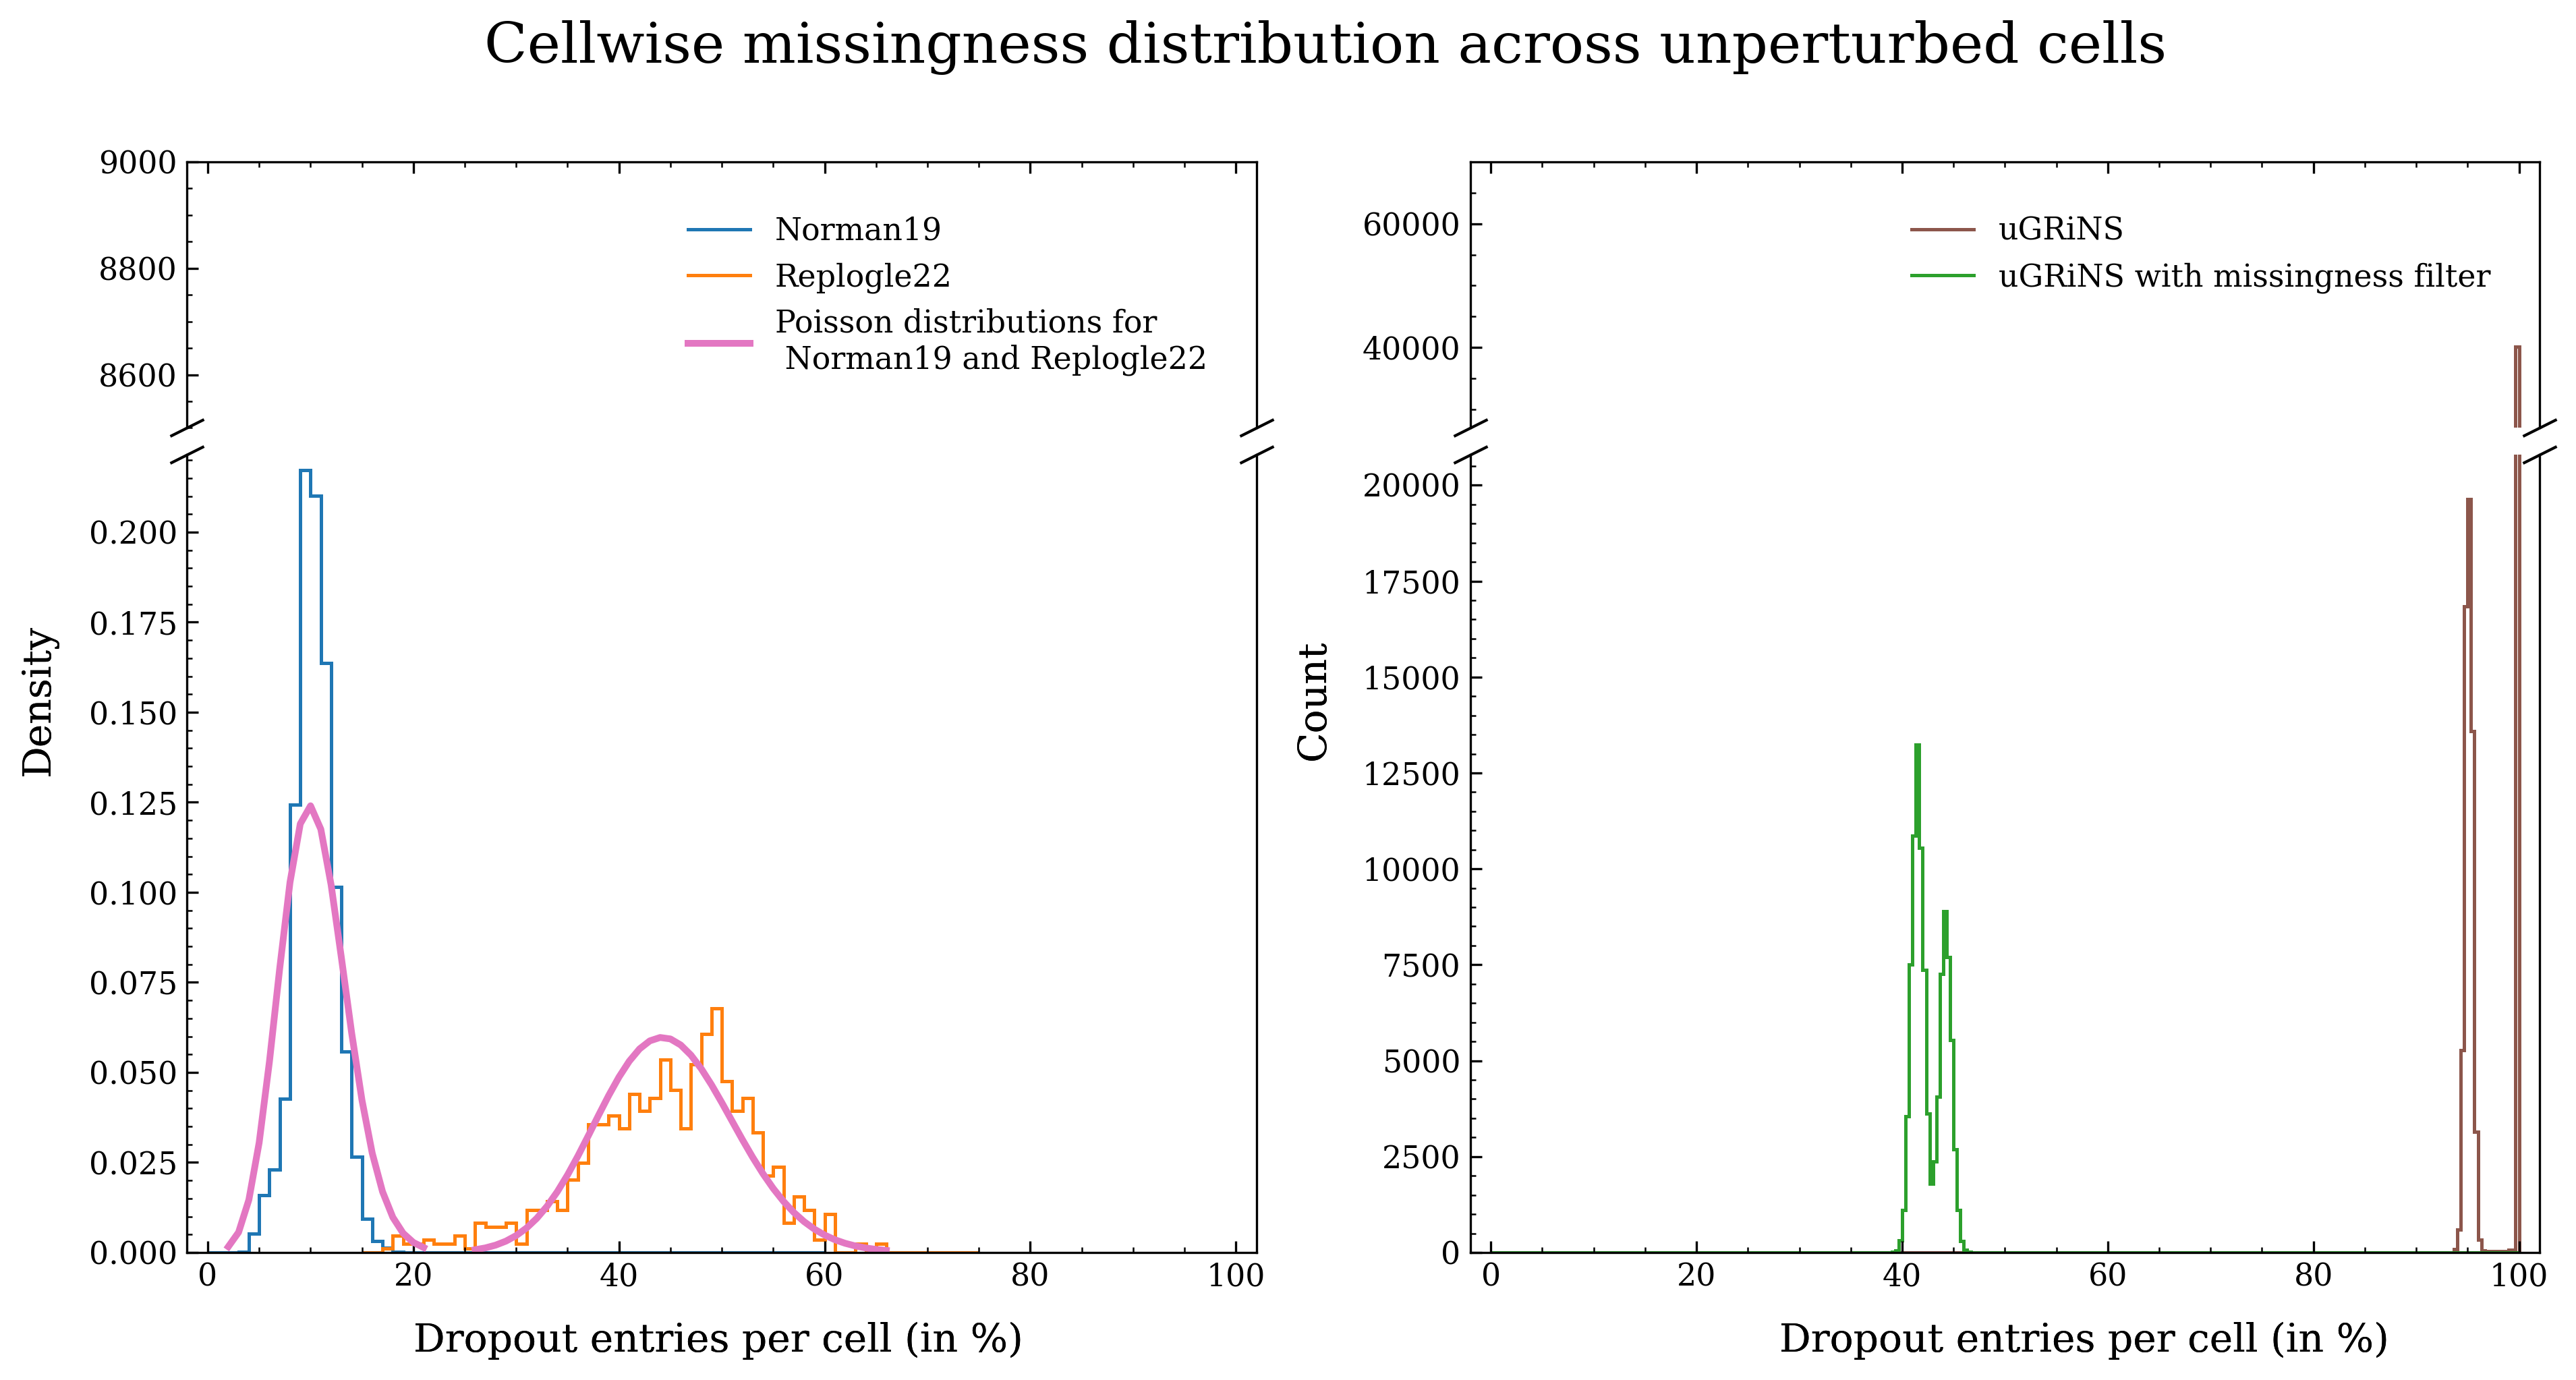

In [45]:
fig, axs = plt.subplots(2, 2, sharex="col",figsize=(15,7),dpi=300,height_ratios=[1,3])
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

bins = 60
replogle_y, replogle_x = np.histogram(list(100*(replogle_data.obs["n_genes_by_counts"]/replogle_data.shape[1])),bins=bins,range=(15,75),density=True)
norman_y, norman_x = np.histogram(list(100*(norman_data.obs["n_genes_by_counts"]/norman_data.shape[1])),bins=bins,range=(0,60),density=True)

grins_y, grins_x = np.histogram(list(100*(grins_data_full.obs["n_genes_by_counts"]/grins_data_full.shape[1])),bins=5*bins,range=(0,100))
miss_grins_y, miss_grins_x = np.histogram(list(100*(grins_data.obs["n_genes_by_counts"]/grins_data.shape[1])),bins=5*bins,range=(0,100))

norman_lamb = np.mean(list(100*(norman_data.obs["n_genes_by_counts"]/norman_data.shape[1])))
norman_poisx = np.arange(poisson.ppf(0.001, norman_lamb),poisson.ppf(0.999, norman_lamb))
norman_pois = poisson.pmf(norman_poisx,norman_lamb)
rep_lamb = np.mean(list(100*(replogle_data.obs["n_genes_by_counts"]/replogle_data.shape[1])))
rep_poisx = np.arange(poisson.ppf(0.001, rep_lamb),poisson.ppf(0.999, rep_lamb))
rep_pois = poisson.pmf(rep_poisx,rep_lamb)

for j in range(2):
    ax1 = axs[0,j]
    ax2 = axs[1,j]
    if j == 0:
        
        ax1.stairs(norman_y,norman_x,label="Norman19",color=prop_cycle[0],lw=lw)
        ax2.stairs(norman_y,norman_x,color=prop_cycle[0],lw=lw)

        ax1.stairs(replogle_y,replogle_x, label="Replogle22",color=prop_cycle[1],lw=lw)
        ax2.stairs(replogle_y,replogle_x,color=prop_cycle[1],lw=lw)
        
        ax1.plot(norman_poisx,norman_pois,label=f"Poisson distributions for \n Norman19 and Replogle22",color=prop_cycle[6],lw=2*lw)
        ax2.plot(norman_poisx,norman_pois,color=prop_cycle[6],lw=2*lw)
        ax1.plot(rep_poisx,rep_pois,color=prop_cycle[6],lw=2*lw)
        ax2.plot(rep_poisx,rep_pois,color=prop_cycle[6],lw=2*lw)

               
    else:
        ax1.stairs(grins_y,grins_x, label="uGRiNS",color=prop_cycle[5],lw=lw)
        ax2.stairs(grins_y,grins_x,color=prop_cycle[5],lw=lw)

        ax1.stairs(miss_grins_y,miss_grins_x, label="uGRiNS with missingness filter",color=prop_cycle[2],lw=lw)
        ax2.stairs(miss_grins_y,miss_grins_x,color=prop_cycle[2],lw=lw)
        
    if j == 1:
        ax2.set_ylim(0,20800)
        ax1.set_ylim(27000,70000)
    else:
        ax1.set_ylim(8500,9000)
    ax1.set_xlim(-2,102)

    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)  # don't put tick labels at the top
    ax2.xaxis.tick_bottom()
    #if j == 1:
    d = .5  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    fig.text(0.3, 0.04, 'Dropout entries per cell (in %)', ha='center')
    fig.text(0.75, 0.04, 'Dropout entries per cell (in %)', ha='center')
    fig.text(0.07, 0.5, 'Density', va='center', rotation='vertical')
    fig.text(0.49, 0.5, 'Count', va='center', rotation='vertical')
    ax1.legend(loc="upper right",bbox_to_anchor=(0.98,0.9))
    plt.suptitle("Cellwise missingness distribution across unperturbed cells")
plt.savefig("Prep_Data/Plots/missingness_cellwise.png")
plt.show()

# Clustering:

## PCA:

In [48]:
grins_data.obs

,PertNum,InitCondNum,ParamNum,perturbation,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,leiden,silhouette_samples,best_cells
-1_1_1,-1,1.0,1.0,ctrl,2020,7.611348,7.728143e+07,18.162964,99.746700,0,0.158215,False
-1_1_2,-1,1.0,2.0,ctrl,2106,7.653020,1.571238e+07,16.569959,98.737631,1,0.328895,False
-1_1_3,-1,1.0,3.0,ctrl,1908,7.554335,1.631016e+05,12.002135,12.483187,2,0.132767,False
-1_1_4,-1,1.0,4.0,ctrl,2075,7.638198,2.064180e+07,16.842829,99.071537,1,0.092841,False
-1_1_5,-1,1.0,5.0,ctrl,2071,7.636270,7.405349e+10,25.028053,99.999708,3,-0.059014,False
...,...,...,...,...,...,...,...,...,...,...,...,...
-1_100_996,-1,100.0,996.0,ctrl,1952,7.577122,1.675681e+05,12.029151,10.095172,2,-0.175107,False
-1_100_997,-1,100.0,997.0,ctrl,2062,7.631917,5.134650e+05,13.148939,62.202785,53,0.575633,False
-1_100_998,-1,100.0,998.0,ctrl,1920,7.560601,1.477316e+05,11.903159,9.010854,41,-0.602883,False
-1_100_999,-1,100.0,999.0,ctrl,2053,7.627544,7.602187e+07,18.146532,99.746290,0,0.368053,False


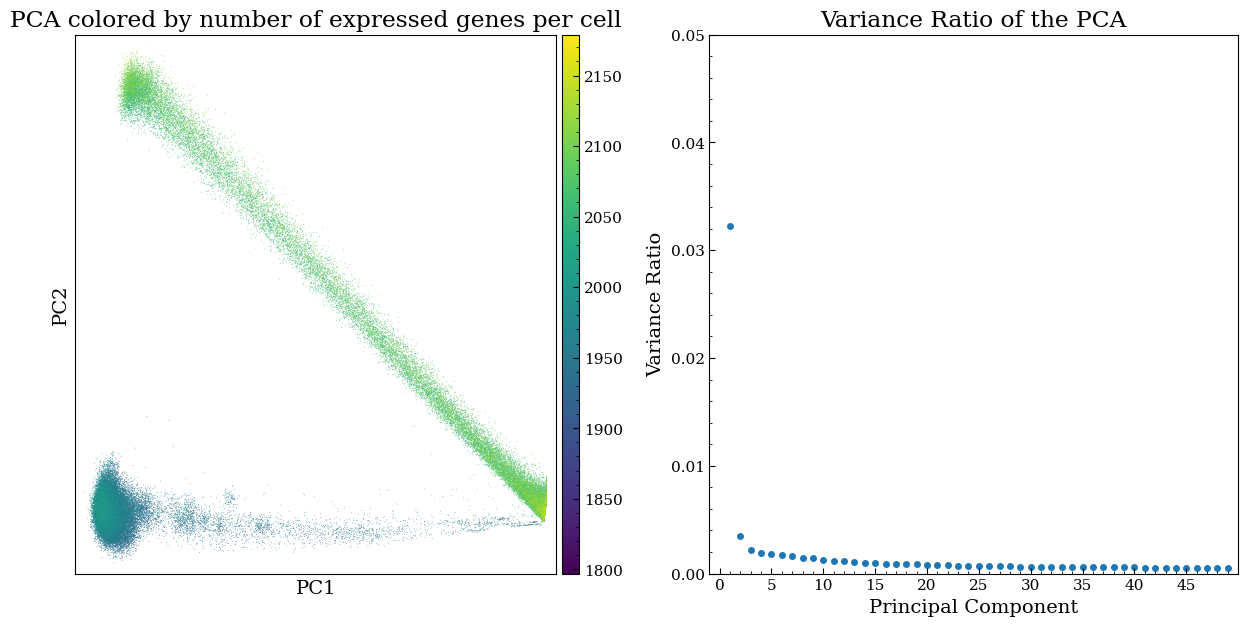

In [53]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
max_pca = 50
axs[1].scatter(range(max_pca),grins_data.uns["pca"]["variance_ratio"][:max_pca])
axs[1].set_xlabel("Principal Component")
axs[1].set_ylabel("Variance Ratio")
axs[1].set_xticks(range(0,max_pca,5))
axs[1].set_ylim(0,0.05)
axs[1].set_title("Variance Ratio of the PCA")
sc.pl.pca(grins_data,color="n_genes_by_counts",layer="log1p",ax=axs[0],title="PCA colored by number of expressed genes per cell")
plt.show()

## UMAP:

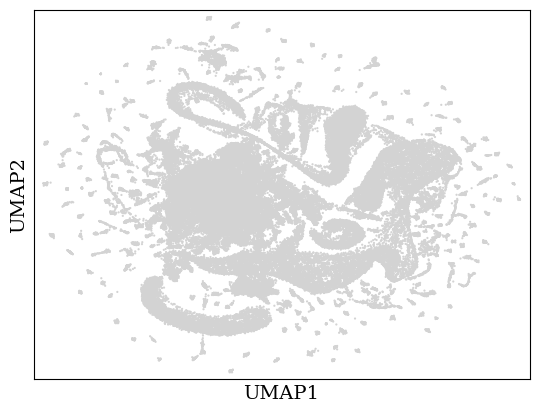

In [17]:
sc.pl.umap(grins_data,s=10)

In [63]:
best_clusters

array(['23', '53', '21', '101', '18', '20', '17', '39', '24', '10'],
      dtype=object)

In [65]:
sample_silhouette_means = [np.mean(sample_silhouette_values[cluster_labels == cluster]) for cluster in best_clusters]

In [67]:
best_clusters

array(['23', '53', '21', '101', '18', '20', '17', '39', '24', '10'],
      dtype=object)

In [75]:
mse_scores

array([1.02608706, 2.31646233, 0.50682428, 3.16933543, 3.31834849,
       0.57928641, 3.30002262, 3.28037629, 3.25673672, 0.52925802])

In [54]:
cluster_labels = grins_data.obs["leiden"]
cluster_counts = cluster_labels.value_counts()
clusters = np.array(list(cluster_counts.keys()))

sample_silhouette_values = np.asarray(grins_data.obs["silhouette_samples"])
best_clusters = grins_data.uns["clustering_results"]["best_clusters"]
best_cluster_size = sum([cluster_counts[c] for c in best_clusters])
n_clusters = len(best_clusters)
mse_scores = grins_data.uns["clustering_results"]["scores"]

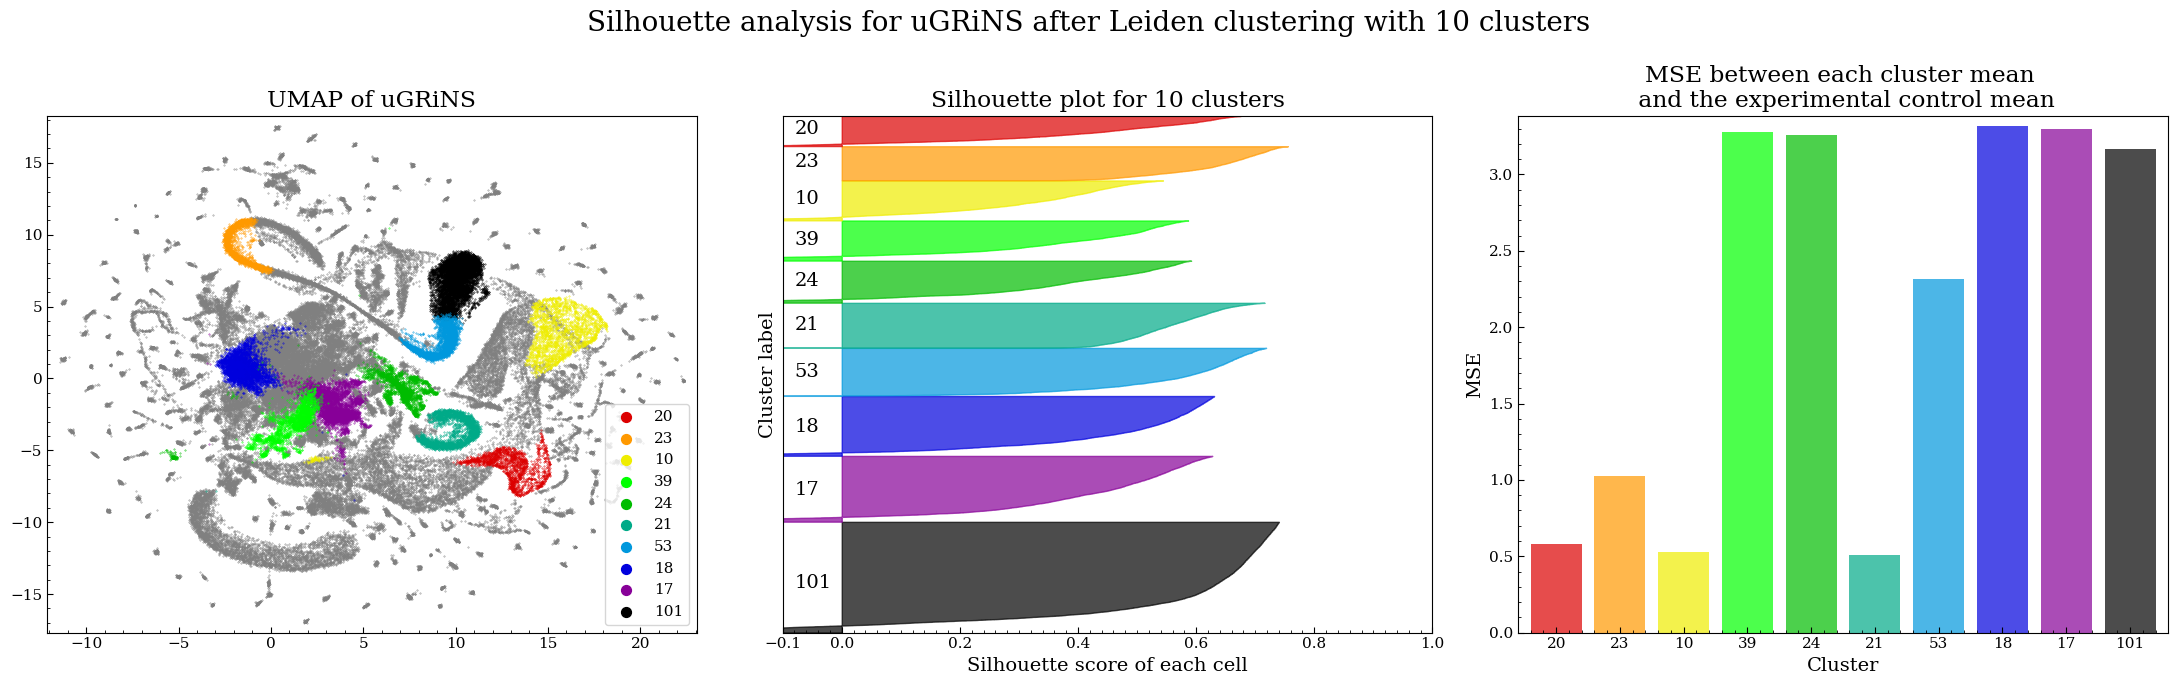

In [74]:
# Modified from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

fig, (ax2,ax1, ax0) = plt.subplots(1, 3)
fig.set_size_inches(22,7)

ax1.set_xlim([-0.1, 1])
ymax = best_cluster_size + (n_clusters + 1) * 10
ax1.set_ylim([0, ymax])

y_lower = 10
cluster_sil_means = []
best_cluster_i = -1

for i in (range(len(clusters))):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    if clusters[i] not in best_clusters:
        continue
    else:
        best_cluster_i += 1
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == clusters[i]]
    sample_silhouette_mean = np.mean(ith_cluster_silhouette_values)
    
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(best_cluster_i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    #ax1.axvline(x=sample_silhouette_mean,ymin=y_lower/ymax,ymax=y_upper/ymax,lw=1.2*lw,color="red", linestyle="dotted")

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.08, y_lower + 0.4 * size_cluster_i, str(clusters[i]))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette plot for %d clusters"% n_clusters)
ax1.set_xlabel("Silhouette score of each cell")
ax1.set_ylabel("Cluster label")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

# Order clusters and MSEs according to the cluster size
best_clusters_ordered = clusters[cluster_counts.keys().isin(best_clusters)]
mse_scores_ordered = [mse_scores[np.where(best_clusters == best_clusters_ordered[i])[0][0]] for i in range(len(best_clusters_ordered))]

y_pos = np.arange(len(best_clusters_ordered))
hbars = ax0.bar(y_pos, mse_scores_ordered, align='center',color=[mpl.colors.to_hex(cm.nipy_spectral(float(i) / n_clusters)) for i in y_pos],alpha=0.7)
ax0.set_xticks(y_pos, labels=best_clusters_ordered)
ax0.invert_xaxis()
ax0.set_xlabel('Cluster')
ax0.set_ylabel('MSE')
ax0.set_title('MSE between each cluster mean \n and the experimental control mean')

ax2.scatter(grins_data.obsm["X_umap"].T[0][~cluster_labels.isin(best_clusters_ordered)],grins_data.obsm["X_umap"].T[1][~cluster_labels.isin(best_clusters_ordered)],s=0.1,c="grey")
for i in range(len(best_clusters_ordered)):
    ax2.scatter(grins_data.obsm["X_umap"].T[0][cluster_labels==best_clusters_ordered[i]],grins_data.obsm["X_umap"].T[1][cluster_labels==best_clusters_ordered[i]],s=0.1,c = mpl.colors.to_hex(cm.nipy_spectral(float(i) / n_clusters)),label=best_clusters_ordered[i])    

handles, labels = ax2.get_legend_handles_labels()
lgnd = ax2.legend(handles[::-1], labels[::-1],frameon=True)
for handle in lgnd.legend_handles:
    handle.set_sizes([50])
ax2.set_title("UMAP of uGRiNS")

plt.suptitle(
    "Silhouette analysis for uGRiNS after Leiden clustering with %d clusters"
    % n_clusters
)
plt.tight_layout()
plt.show()